In [5]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
url = 'https://data.montgomerycountymd.gov/resource/v76h-r7br.csv?$limit=350000&$offset=0'

In [7]:
data = pd.read_csv(url)
df = data.copy()

In [8]:
df.head()

,calendar_year,cal_month_num,supplier,item_code,item_description,item_type,rtl_sales,rtl_transfers,whs_sales
0,2026,8,20705 IMPORTS,180363,CAN' LEANDRO LES FINQUES 750ML,WINE,0.00,0.0,1.0
1,2026,8,20705 IMPORTS,171162,PROSECCO 84 - 750ML,WINE,0.00,0.0,7.0
2,2026,8,20705 IMPORTS,180424,FENTO BICO DA RAN ALBARINO 750ML,WINE,0.00,0.0,1.0
3,2026,8,20705 IMPORTS,171163,BENNATI CASTELLANO PINOT GRIGIO 750ML,WINE,0.00,0.0,10.0
4,2026,8,AFARO LLC,348420,CH ROCHER CALON ST. EMILION - 750ML,WINE,3.41,2.0,0.0


__The cell above uses the .head() method to display the first 5 rows of data from the dataframe.__

In [9]:
df.shape

(341037, 9)

__The above cell shows there are 9 columns and 330080 rows.__

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341037 entries, 0 to 341036
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   calendar_year     341037 non-null  int64  
 1   cal_month_num     341037 non-null  int64  
 2   supplier          340833 non-null  object 
 3   item_code         341037 non-null  object 
 4   item_description  341037 non-null  object 
 5   item_type         341036 non-null  object 
 6   rtl_sales         341031 non-null  float64
 7   rtl_transfers     341037 non-null  float64
 8   whs_sales         341037 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 23.4+ MB


 __In the above cell, we can see there are some null values in supplier, item_type, and rtl_sales.__

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(340832, 9)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 340832 entries, 0 to 341033
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   calendar_year     340832 non-null  int64  
 1   cal_month_num     340832 non-null  int64  
 2   supplier          340832 non-null  object 
 3   item_code         340832 non-null  object 
 4   item_description  340832 non-null  object 
 5   item_type         340832 non-null  object 
 6   rtl_sales         340832 non-null  float64
 7   rtl_transfers     340832 non-null  float64
 8   whs_sales         340832 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 26.0+ MB


__The null values have been dropped and the amount dropped is insignificant.__

In [14]:
df.describe()

,calendar_year,cal_month_num,rtl_sales,rtl_transfers,whs_sales
count,340832.000000,340832.000000,340832.000000,340832.000000,340832.000000
mean,2019.178258,6.479186,6.911413,6.909362,25.610778
std,2.471134,3.302280,29.969920,30.062321,249.065059
min,2017.000000,1.000000,-6.490000,-38.490000,-4996.000000
25%,2017.000000,3.000000,0.000000,0.000000,0.000000
50%,2019.000000,7.000000,0.250000,0.000000,1.000000
75%,2019.000000,9.000000,3.260000,3.000000,5.000000
max,2026.000000,12.000000,1816.490000,1990.830000,18317.000000


__The cell above uses the .describe() method to give summary statistics of the quantitative columns.__

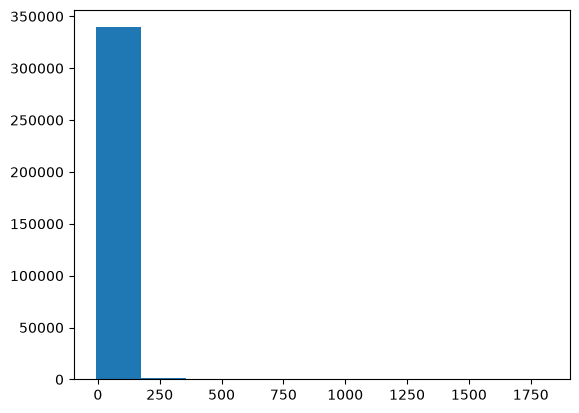

In [15]:
plt.hist(df['rtl_sales'])
plt.show()

__The histogram above shows that the vast majority of retail sales is no more than about $200.__

In [16]:
df.rtl_sales.value_counts()

rtl_sales
0.00      137330
0.08       11151
0.17        7535
0.16        6365
0.24        4140
           ...  
65.38          1
78.60          1
63.62          1
635.24         1
84.98          1
Name: count, Length: 11007, dtype: int64

__To analyze the data based on total sales, we need to combine the rtl_sales and whs_sales columns.__

In [17]:
df['total_sales'] = df['rtl_sales'] + df['whs_sales']

In [18]:
df.head()

,calendar_year,cal_month_num,supplier,item_code,item_description,item_type,rtl_sales,rtl_transfers,whs_sales,total_sales
0,2026,8,20705 IMPORTS,180363,CAN' LEANDRO LES FINQUES 750ML,WINE,0.00,0.0,1.0,1.00
1,2026,8,20705 IMPORTS,171162,PROSECCO 84 - 750ML,WINE,0.00,0.0,7.0,7.00
2,2026,8,20705 IMPORTS,180424,FENTO BICO DA RAN ALBARINO 750ML,WINE,0.00,0.0,1.0,1.00
3,2026,8,20705 IMPORTS,171163,BENNATI CASTELLANO PINOT GRIGIO 750ML,WINE,0.00,0.0,10.0,10.00
4,2026,8,AFARO LLC,348420,CH ROCHER CALON ST. EMILION - 750ML,WINE,3.41,2.0,0.0,3.41


__Next, to simplify the dataframe, we will drop the unneeded columns. For future use of the analysis, it will be useful to keep some of the rows that aren't going to be used in the mulitple linear regression model.__

In [19]:
df.drop(columns=['calendar_year', 'cal_month_num', 'rtl_sales', 'rtl_transfers', 'whs_sales'], inplace=True)

In [20]:
df.head()

,supplier,item_code,item_description,item_type,total_sales
0,20705 IMPORTS,180363,CAN' LEANDRO LES FINQUES 750ML,WINE,1.00
1,20705 IMPORTS,171162,PROSECCO 84 - 750ML,WINE,7.00
2,20705 IMPORTS,180424,FENTO BICO DA RAN ALBARINO 750ML,WINE,1.00
3,20705 IMPORTS,171163,BENNATI CASTELLANO PINOT GRIGIO 750ML,WINE,10.00
4,AFARO LLC,348420,CH ROCHER CALON ST. EMILION - 750ML,WINE,3.41


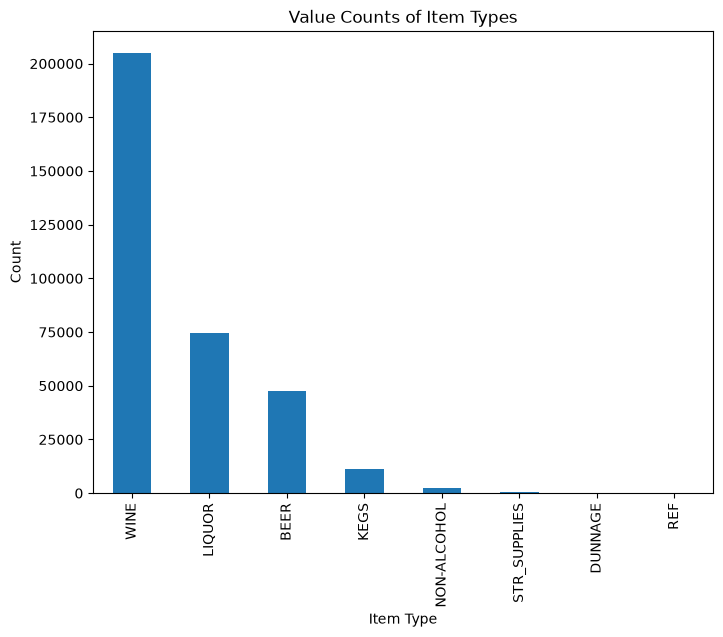

In [21]:
counts = df.item_type.value_counts()

counts.plot(kind='bar', figsize=(8,6))
plt.xlabel('Item Type')
plt.ylabel('Count')
plt.title('Value Counts of Item Types')
plt.show()


__Above we see a breakdown of total counts of item types in a bar chart. The vast majority of items are wine, though this is graph does not have any relationship with total sales. We need to determine what STR_SUPPLIES, REF, and DUNNAGE are as they may not benefit the analysis.__

In [22]:
df[df['item_type'] == 'REF']

,supplier,item_code,item_description,item_type,total_sales
35553,Default,112,CORKSCREW,REF,8.55
47066,Default,112,CORKSCREW,REF,8.17
58323,Default,112,CORKSCREW,REF,22.08
69911,Default,59781,STORE SPECIAL WINE 750 ML - 750ML,REF,-0.08
69914,Default,112,CORKSCREW,REF,16.10
...,...,...,...,...,...
317566,Default,59781,STORE SPECIAL WINE 750 ML - 750ML,REF,23.84
317567,Default,59668,STORE SPECIAL WINE 355 ML - 355ML,REF,22.78
330796,Default,59781,STORE SPECIAL WINE 750 ML - 750ML,REF,1.65
330797,Default,59668,STORE SPECIAL WINE 355 ML - 355ML,REF,8.55


__The above cell shows that REF appears to mean refund. This will not pertain to our model in which we are trying to predict total sales, as refunds can occur for various reasons and does not have to do with the ability for an item to sell. The rows where item_type is REF will be dropped.__ 

In [23]:
df = df[df['item_type'] != 'REF']

In [24]:
df[df.item_type == 'STR_SUPPLIES']

,supplier,item_code,item_description,item_type,total_sales
1730,Default,112,CORKSCREW,STR_SUPPLIES,3.89
1731,Default,114,WINE PAPER GIFT TOTE SINGLE BOTTLE,STR_SUPPLIES,85.46
1732,Default,102,FLEX SEAL WINE STOPPER,STR_SUPPLIES,2.80
1733,Default,128,BEVERAGE STIRRERS TRANSLUCENT,STR_SUPPLIES,0.08
1734,Default,110,WINE BOTTLE TOTE 6 BTL HEAVY DUTY,STR_SUPPLIES,0.20
...,...,...,...,...,...
333859,KAHN PAPER COMPANY INC,8028,BAGS - PAPER 20LB,STR_SUPPLIES,0.00
333860,KAHN PAPER COMPANY INC,8001,BAGS - PAPER 1/6 BARREL,STR_SUPPLIES,0.00
333861,KAHN PAPER COMPANY INC,8036,BAGS - PAPER 12LB,STR_SUPPLIES,0.00
333862,KAHN PAPER COMPANY INC,8044,BAGS - PAPER PINTS,STR_SUPPLIES,0.00


In [25]:
df[df.item_type =='STR_SUPPLIES'].item_description.value_counts()

item_description
WINE PAPER GIFT TOTE SINGLE BOTTLE      27
THERMAL REGISTER PAPER                  27
BAGS - PAPER PINTS                      27
BAGS - PAPER 1/6 BARREL                 26
BAGS - PAPER 20LB                       26
WINE GIFT TOTE SINGLE BOTTLE            26
BAGS - PAPER 12LB                       25
SIX BOTTLE WINE TOTE (NO LOGO)          24
FOUR BOTTLE WINE TOTE                   24
BAGS - PAPER QUARTS                     22
WINE BOTTLE TOTE 6 BTL HEAVY DUTY       19
BAGS - PLASTIC 20LB                     18
WINE AERATOR-IN BOTTLE                  15
WINE TOTE WOOD HANDLE 2 POCKET 4 BTL    15
TWO BOTTLE WINE TOTE                    14
WINE GIFT TOTE 4 BOTTLE                  4
WINE STOPPER-POURER - 2-PACK             4
BARSMITH DEHYDRATED LIMES - 1.3OZ        3
BARSMITH DEHYDRATED LEMONS - 1.3OZ       3
FLEX SEAL WINE STOPPER                   3
BEVERAGE STIRRERS TRANSLUCENT            3
CORKSCREW                                3
WHISTLEPIG MAPLE SYRUP - 375ML       

__Most of the STR_SUPPLIES item type appear to be store supplies and there are very little as there is. This will not prove meaningful to the analysis due to the small volume of data and also that most of the items will have 0 in total sales The rows where item type is STR_SUPPLIES will be dropped.__

In [26]:
df = df[df['item_type'] != 'STR_SUPPLIES']

In [27]:
df[df.item_type == 'DUNNAGE']

,supplier,item_code,item_description,item_type,total_sales
214,ANHEUSER BUSCH INC,205,EMPTY 1/6 KEG (30.00),DUNNAGE,-780.0
276,ANHEUSER BUSCH INC,264,EMPTY 1/4 KEG (30.00),DUNNAGE,-269.0
6382,PREMIUM DISTRIBUTORS INC,175,EMPTY 1/2 KEG (30.00),DUNNAGE,-2395.0
11107,ANHEUSER BUSCH INC,205,EMPTY 1/6 KEG (30.00),DUNNAGE,-791.0
11224,ANHEUSER BUSCH INC,264,EMPTY 1/4 KEG (30.00),DUNNAGE,-291.0
...,...,...,...,...,...
314519,ANHEUSER BUSCH INC,264,EMPTY 1/4 KEG (30.00),DUNNAGE,-322.0
314586,ANHEUSER BUSCH INC,175,EMPTY 1/2 KEG (30.00),DUNNAGE,-4364.0
327492,ANHEUSER BUSCH INC,205,EMPTY 1/6 KEG (30.00),DUNNAGE,-1208.0
327666,ANHEUSER BUSCH INC,175,EMPTY 1/2 KEG (30.00),DUNNAGE,-4804.0


__The above cell shows that DUNNAGE appears to be empty keg returns. The analysis is meant to see if there is any significance in item type to higher total sales. A keg return does not relate to the sale of the item. The rows where item type is DUNNAGE will be dropped.__

In [28]:
df = df[df['item_type'] != 'DUNNAGE']

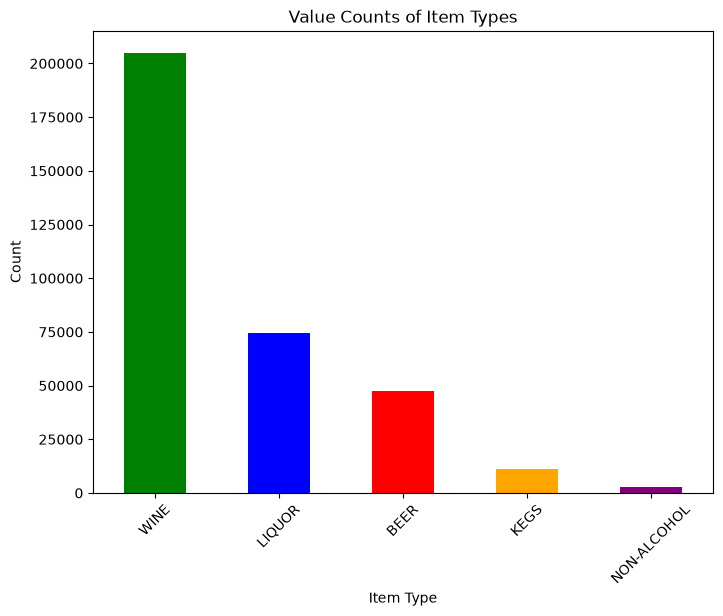

In [29]:
counts = df.item_type.value_counts()
colors = ['green', 'blue', 'red', 'orange', 'purple']

counts.plot(kind='bar', figsize=(8,6), color=colors)
plt.xlabel('Item Type')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.title('Value Counts of Item Types')
plt.show()

In [30]:
df.describe()

,total_sales
count,340308.000000
mean,32.952469
std,263.104631
min,-229.333330
25%,1.000000
50%,2.740000
75%,10.670000
max,19491.000000


__The median of total sales in the data now is 2.73 and the mean is 33.025169. It appears there may be some outliers on the minimum and maximum.__

In [31]:
df.sort_values(by='total_sales', ascending=False).head(25)

,supplier,item_code,item_description,item_type,total_sales
46975,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,19491.00000
157529,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,19076.62499
132710,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,19008.87499
262844,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,17071.12500
304085,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,16336.70833
145166,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,16233.91667
120234,CROWN IMPORTS,96750,CORONA EXTRA 2/12 NR - 12OZ,BEER,16053.30000
330736,CROWN IMPORTS,96750,CORONA EXTRA 2/12 NR - 12OZ,BEER,16008.45833
107839,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,15483.00000
69830,CROWN IMPORTS,23445,CORONA EXTRA LOOSE NR - 12OZ,BEER,15087.49999


__It appears that beer is consistently selling over $10,000 and are similar item descriptions. I see no outliers to remove.__

In [32]:
df.sort_values(by='total_sales').head(25)

,supplier,item_code,item_description,item_type,total_sales
314623,ANHEUSER BUSCH INC,84938,BUD SUMMER CAMO ALUMINUM BTL 16.0Z 3/8 PK,BEER,-229.33333
314656,ANHEUSER BUSCH INC,12870,MICHELOB ULTRA 160Z. ALUMIMUN GOLF 24 PK NR,BEER,-229.00000
37510,HEINEKEN USA,37015,HEINEKEN 0.0 1/15 MIX CAN,BEER,-91.00000
314655,ANHEUSER BUSCH INC,12871,BUD LIGHT LIME 24/16 CAL NR 3/8PK,BEER,-46.00000
320522,KATCEF BROTHERS INC,12872,DEVILS BACKBONE VIENNA LAGER 24PK 16.0Z CAN,BEER,-31.00000
124682,MONSIEUR TOUTON SELECTION,233314,DOM DE LA CHANADE-LES RIALS - 750ML,WINE,-19.00000
294411,LEGENDS LTD,12480,KOSTRITZER - 6/4 16.OZ CAN,BEER,-18.00000
318890,E & J GALLO WINERY,310155,WM HILL CENTRAL COAST CAB - 750ML,WINE,-16.50333
318856,E & J GALLO WINERY,302971,WM HILL CENTRAL COAST CHARD - 750ML,WINE,-15.04667
314558,ANHEUSER BUSCH INC,30887,BLUE POINT TOASTED LAGER 16OZ CAN,BEER,-15.00000


__I do not believe the two lowest negative values here are far enough apart from the third row to call them outliers. The two lowest values rows are nearly the same value, thus leading me to believe they are a realistic value. I see no outliers here.__

In [33]:
grouped_sales = df.groupby('item_type')['total_sales'].sum()
grouped_sales = grouped_sales.sort_values(ascending=False)
grouped_sales

item_type
BEER           7.897215e+06
WINE           2.070244e+06
LIQUOR         1.049076e+06
KEGS           1.297700e+05
NON-ALCOHOL    6.768351e+04
Name: total_sales, dtype: float64

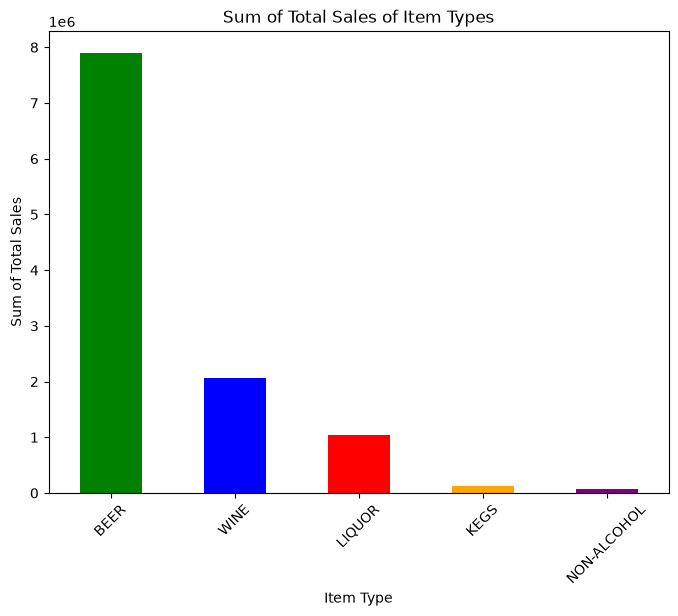

In [34]:
colors = ['green', 'blue', 'red', 'orange', 'purple']
grouped_sales.plot(kind='bar', figsize=(8,6), color=colors)
plt.xlabel('Item Type')
plt.xticks(rotation=45)
plt.ylabel('Sum of Total Sales')
plt.title('Sum of Total Sales of Item Types')
plt.show()

__We have now grouped the total sales by item type and displayed them in a bar chart. Previously shown, wine is the most common item, but shown in this bar chart beer has far more total sales. Neither of these indicates statistical significance between item price and total sales, though it makes one think that beer is more likely to have statistical significance just based upon the exploratory analytic visuals we have seen. This will need to be further analyzed before any proper statement can be made.__ 

In [35]:
pd.get_dummies(df['item_type'], dtype=int)

,BEER,KEGS,LIQUOR,NON-ALCOHOL,WINE
0,0,0,0,0,1
1,0,0,0,0,1
2,0,0,0,0,1
3,0,0,0,0,1
4,0,0,0,0,1
...,...,...,...,...,...
341029,0,0,0,0,1
341030,0,0,0,0,1
341031,0,0,0,0,1
341032,0,0,0,0,1


__In order for the multiple linear regression model to work properly, we one-hot encoded our categorical item type values. This places a 1 in the column of what the item type is and a 0 in the column of the item type of what it isn't.__

In [36]:
df[['BEER', 'KEGS', 'LIQUOR', 'NON-ALCOHOL', 'WINE']] = pd.get_dummies(df['item_type'], dtype=int)

__Now the actual one-hot encoded columns have been added to the dataframe. Below, we will show a few rows of each item type to verify it worked properly.__

In [37]:
df[df.item_type == 'BEER'].head(3)

,supplier,item_code,item_description,item_type,total_sales,BEER,KEGS,LIQUOR,NON-ALCOHOL,WINE
34,ALLAGASH BREWING COMPANY,92647,ALLAGASH BREWING VARIETY PACK 2/12 CANS,BEER,10.0,1,0,0,0,0
35,ALLAGASH BREWING COMPANY,60877,ALLAGASH CURIEUX 6/4 NR,BEER,4.0,1,0,0,0,0
38,ALLAGASH BREWING COMPANY,69536,ALLAGASH WHITE 2/12 CANS,BEER,42.0,1,0,0,0,0


In [38]:
df[df.item_type == 'KEGS'].head(3)

,supplier,item_code,item_description,item_type,total_sales,BEER,KEGS,LIQUOR,NON-ALCOHOL,WINE
36,ALLAGASH BREWING COMPANY,12151,ALLAGASH CURIEUX 1/2 KEG,KEGS,1.0,0,1,0,0,0
37,ALLAGASH BREWING COMPANY,25826,ALLAGASH WHITE 1/6K,KEGS,5.0,0,1,0,0,0
39,ALLAGASH BREWING COMPANY,2194,ALLAGASH WHITE 1/2K,KEGS,14.0,0,1,0,0,0


In [39]:
df[df.item_type == 'LIQUOR'].head(3)

,supplier,item_code,item_description,item_type,total_sales,BEER,KEGS,LIQUOR,NON-ALCOHOL,WINE
32,AHAWC LLC,17216,WISHER VODKA 750ML,LIQUOR,2.87,0,0,1,0,0
79,AMERICAN VINTAGE BEVERAGE INC,89042,GLENDALOUGH 7YR IRISH SINGLE MALT WHISKEY - 750ML,LIQUOR,0.85,0,0,1,0,0
85,ANHEUSER BUSCH INC,91663,DEVILS BACKBONE TEQUILA LIME MARGARITA RTD 6/4...,LIQUOR,51.13,0,0,1,0,0


In [40]:
df[df.item_type == 'NON-ALCOHOL'].head(3)

,supplier,item_code,item_description,item_type,total_sales,BEER,KEGS,LIQUOR,NON-ALCOHOL,WINE
46,AMERICAN BEVERAGE MARKETERS,297259,MASTER OF MIXES COCKTAIL ESSENTIALS PEACH 375ML,NON-ALCOHOL,2.16,0,0,0,1,0
47,AMERICAN BEVERAGE MARKETERS,70691,MASTER OF MIXES STR/DAQ/MAR - 1.75L,NON-ALCOHOL,8.42,0,0,0,1,0
48,AMERICAN BEVERAGE MARKETERS,297253,MASTER OF MIXES COCKTAIL ESSENTIALS STRAWBERRY...,NON-ALCOHOL,4.65,0,0,0,1,0


In [41]:
df[df.item_type == 'WINE'].head(3)

,supplier,item_code,item_description,item_type,total_sales,BEER,KEGS,LIQUOR,NON-ALCOHOL,WINE
0,20705 IMPORTS,180363,CAN' LEANDRO LES FINQUES 750ML,WINE,1.0,0,0,0,0,1
1,20705 IMPORTS,171162,PROSECCO 84 - 750ML,WINE,7.0,0,0,0,0,1
2,20705 IMPORTS,180424,FENTO BICO DA RAN ALBARINO 750ML,WINE,1.0,0,0,0,0,1


__All of the item types are one-hot encoded properly. Now, we need to make the intercept, which is the item type group that will be the baseline, or reference group.__

In [42]:
df['intercept'] = 1

In [43]:
lm = sm.OLS(df['total_sales'], df[['intercept', 'KEGS', 'LIQUOR', 'NON-ALCOHOL', 'WINE']])
results = lm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            total_sales   R-squared:                       0.042
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     3708.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:52:10   Log-Likelihood:            -2.3720e+06
No. Observations:              340308   AIC:                         4.744e+06
Df Residuals:                  340303   BIC:                         4.744e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept     166.4288      1.182    140.761      0.000     164.111     168.746
KEGS         -154.6860      2.720    -56.862      0.000    -160.018    -149.354
LIQUOR       -152.3185      1.513   -100.652      0.000    -155.285    -149.352
NON-ALCOHOL  -140.3265      5.194    -27.016      0.000    -150.507    -130.146
WINE         -156.3234      1.312   -119.135      0.000    -158.895    -153.752
==============================================================================
Omnibus:                   881275.066   Durbin-Watson:                   1.664
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      24596809458.991
Skew:                          29.937   Prob(JB):                         0.00
Kurtosis:                    1318.709   Cond. No.                         14.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

__Beer, as the intercept, has the statistically highest value of all the item types shown by the "coef". If beer is selling at 167, kegs are selling at -155, over 300 less than beer. Though, due to the R-squared value of 0.042, this means that only 4.2% of the variance is actually explained by item type. The P-values are showing zero because they are incredibly small, but not zero. This is likely due to the extremely large size of the dataset, which is over 300k. The Kurtosis value of 1321 is incredibly high. This means the distribution has massive outliers, which I previously misjudged and should have realized upon seeing the histogram for rtl_sales.__ 

__To reduce the effect of the outliers, we will log transform total sales. To reduce the effect of the large dataset, we will use sampling.__

__In order to log transform the data, we will need to replace any negative values with zero.__

In [44]:
df['log_total_sales'] = np.log1p(df['total_sales'].clip(lower=0))

In [45]:
df.head()

,supplier,item_code,item_description,item_type,total_sales,BEER,KEGS,LIQUOR,NON-ALCOHOL,WINE,intercept,log_total_sales
0,20705 IMPORTS,180363,CAN' LEANDRO LES FINQUES 750ML,WINE,1.00,0,0,0,0,1,1,0.693147
1,20705 IMPORTS,171162,PROSECCO 84 - 750ML,WINE,7.00,0,0,0,0,1,1,2.079442
2,20705 IMPORTS,180424,FENTO BICO DA RAN ALBARINO 750ML,WINE,1.00,0,0,0,0,1,1,0.693147
3,20705 IMPORTS,171163,BENNATI CASTELLANO PINOT GRIGIO 750ML,WINE,10.00,0,0,0,0,1,1,2.397895
4,AFARO LLC,348420,CH ROCHER CALON ST. EMILION - 750ML,WINE,3.41,0,0,0,0,1,1,1.483875


__Now that total sales has been log transformed, we will use stratified sampling to ensure that all item types are proportionately represented.__

In [46]:
df_samp = df.groupby('item_type').sample(frac=0.1, random_state = 21)

__In the above cell, we create a stratified sample dataframe where each item type has 10% of its total rows in the sample dataframe. This is implemented by the frac=0.1 argument.__

In [47]:
df_samp.head()

,supplier,item_code,item_description,item_type,total_sales,BEER,KEGS,LIQUOR,NON-ALCOHOL,WINE,intercept,log_total_sales
307888,LEGENDS LTD,29061,BRECKENRIDGE BRECK IPA 4/6 12.OZ NR,BEER,2.00000,1,0,0,0,0,1,1.098612
151365,RELIABLE CHURCHILL LLLP,93434,ROCHEFORT # 6 3/4NR - 11.2OZ,BEER,1.00000,1,0,0,0,0,1,0.693147
330755,CROWN IMPORTS,28618,CORONA EXTRA 18PK CAN 12OZ,BEER,1284.61111,1,0,0,0,0,1,7.158989
191626,ST KILLIAN IMPORTING CO INC,96270,CARLSBERG ELEPHANT 4/6 NR - 12OZ,BEER,74.50000,1,0,0,0,0,1,4.324133
159816,HEINEKEN USA,96610,MORETTI 4/6 NR - 12OZ,BEER,38.75000,1,0,0,0,0,1,3.682610


In [48]:
lm = sm.OLS(df_samp['log_total_sales'], df_samp[['intercept', 'KEGS', 'LIQUOR', 'NON-ALCOHOL', 'WINE']])
results = lm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_total_sales   R-squared:                       0.116
Model:                            OLS   Adj. R-squared:                  0.116
Method:                 Least Squares   F-statistic:                     1117.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        19:52:11   Log-Likelihood:                -57500.
No. Observations:               34030   AIC:                         1.150e+05
Df Residuals:                   34025   BIC:                         1.151e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       2.8825      0.019    151.451      0.000       2.845       2.920
KEGS           -1.2909      0.044    -29.477      0.000      -1.377      -1.205
LIQUOR         -1.2945      0.024    -53.141      0.000      -1.342      -1.247
NON-ALCOHOL    -0.7409      0.084     -8.856      0.000      -0.905      -0.577
WINE           -1.3915      0.021    -65.877      0.000      -1.433      -1.350
==============================================================================
Omnibus:                     4117.943   Durbin-Watson:                   1.988
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5869.574
Skew:                           0.936   Prob(JB):                         0.00
Kurtosis:                       3.797   Cond. No.                         14.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

__The R-squared value has risen from 4.2% to around 12% (it fluctuates a little each time I run the model). This is a significant increase and shows the model is healthier than the previous one. The Kurtosis drastically reduced to about 3.7, which is nearing a normal distribution. The P-values are still showing zero, though they are not zero they are just incredibly small, and the number of rows is 32937. We will reduce this sample size even more to see if the significance beer is currently showing in relation to the other item types remains.__

In [49]:
df_samp = df.groupby('item_type').sample(frac=0.02, random_state = 21)

In [50]:
lm = sm.OLS(df_samp['log_total_sales'], df_samp[['intercept', 'KEGS', 'LIQUOR', 'NON-ALCOHOL', 'WINE']])
results = lm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        log_total_sales   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     218.6
Date:                Thu, 10 Sep 2026   Prob (F-statistic):          9.01e-177
Time:                        19:52:11   Log-Likelihood:                -11476.
No. Observations:                6806   AIC:                         2.296e+04
Df Residuals:                    6801   BIC:                         2.300e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
intercept       2.8704      0.042     67.669      0.000       2.787       2.954
KEGS           -1.1731      0.098    -12.019      0.000      -1.364      -0.982
LIQUOR         -1.2987      0.054    -23.921      0.000      -1.405      -1.192
NON-ALCOHOL    -0.6939      0.186     -3.728      0.000      -1.059      -0.329
WINE           -1.3678      0.047    -29.055      0.000      -1.460      -1.275
==============================================================================
Omnibus:                      795.448   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1111.070
Skew:                           0.920   Prob(JB):                    5.42e-242
Kurtosis:                       3.729   Cond. No.                         14.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

__The R-squared value has increased slightly to a little more than 13% (it fluctuates sometimes each time I run the model), while the number of rows in the sample has reduced to 6587. The P-values of beer in relation to all the other item types remain 0.000, which again is not zero, they are just so small they aren't displayed. This indicates that in relation to all other item types in the model, there is statistical significance that beer has higher total sales than other item types.__

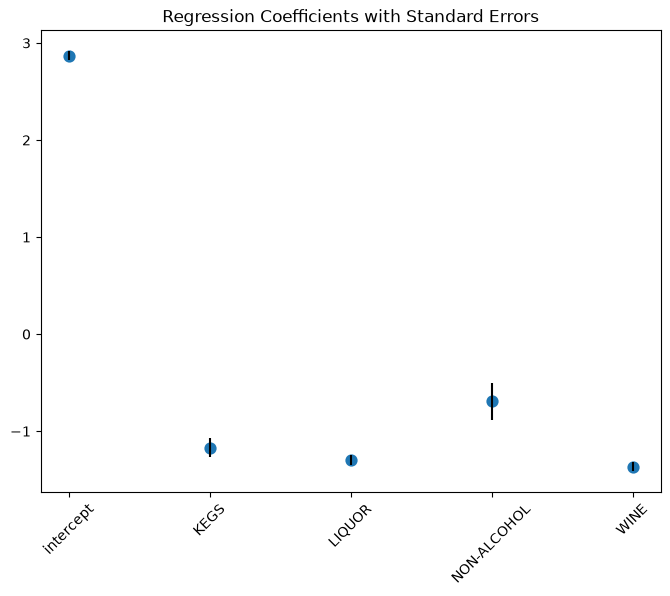

In [51]:
coef = results.params
err = results.bse

plt.figure(figsize=(8,6))
sns.pointplot(x=list(coef.index), y=coef.values, linestyle='none')
plt.errorbar(x=list(coef.index), y=coef.values, yerr=err, fmt='none', c='black')
plt.title("Regression Coefficients with Standard Errors")
plt.xticks(rotation=45)
plt.show()

__The above regression coefficient plot shows each the effect of each item type relative to the intercept (BEER). The vertical black lines indicate standard errors and how confident the model is about each of the estimates. The shorter the vertical line, the more confident the model is in the estimation. The visualization helps to show that it is statistically significant that BEER is much higher in total sales compared to the other item types.__